In [ ]:
#Install Yolo
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
#download dataset dari kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("antoreepjana/animals-detection-images-dataset")

print("Path to dataset files:", path)

100%|██████████| 8.92G/8.92G [01:53<00:00, 84.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root, len(files))

/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7 0
/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test 0
/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test/Goose 33
/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test/Goose/Label 33
/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test/Deer 177
/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test/Deer/Label 177
/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test/Turtle 5
/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test/Turtle/Label 5
/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test/Mule 36
/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-datas

In [ ]:
#buat folder yolo baru
import os

base = "/content/dataset"
os.makedirs(f"{base}/images", exist_ok=True)
os.makedirs(f"{base}/labels", exist_ok=True)

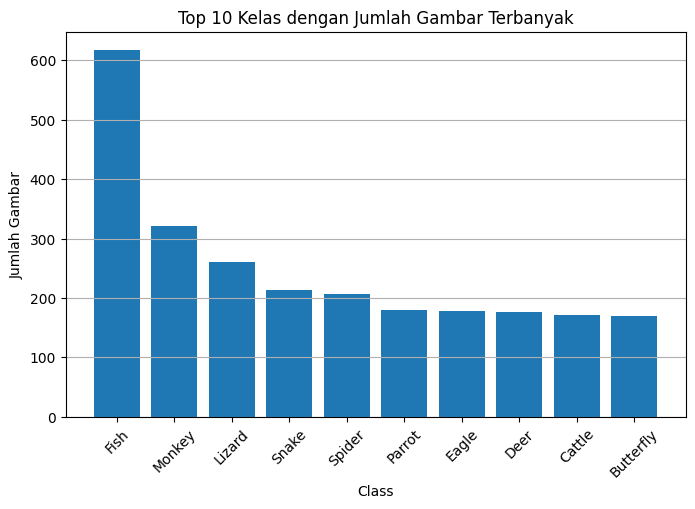

In [ ]:
import matplotlib.pyplot as plt

# GANTI dengan path dataset kamu
base_path = "/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test"

# ambil nama-nama folder kelas
classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

# hitung gambar per kelas
count_per_class = {}
for cls in classes:
    img_path = os.path.join(base_path, cls)
    total_images = len([f for f in os.listdir(img_path) if f.lower().endswith((".jpg", ".png", ".jpeg"))])
    count_per_class[cls] = total_images

# ambil 10 kelas terbanyak
top10 = dict(sorted(count_per_class.items(), key=lambda x: x[1], reverse=True)[:10])

# Plot
plt.figure(figsize=(8,5))
plt.bar(top10.keys(), top10.values())
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")
plt.title("Top 10 Kelas dengan Jumlah Gambar Terbanyak")
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#copy semua foto ke folder images
import shutil

source = "/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test"

for cls in os.listdir(source):
    cls_path = os.path.join(source, cls)
    if os.path.isdir(cls_path):
        img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        for img in img_files:
            shutil.copy(os.path.join(cls_path, img), f"{base}/images/{cls}_{img}")

In [ ]:
#copy semua label ke folder label
for cls in os.listdir(source):
    label_path = os.path.join(source, cls, "Label")
    if os.path.isdir(label_path):
        for label in os.listdir(label_path):
            shutil.copy(os.path.join(label_path, label), f"{base}/labels/{cls}_{label}")

In [ ]:
!sed -n '1,50p' "/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test/Goose/Label/033a2d3f9eac6188.txt"

Goose 159.55968000000001 41.94432 583.926784 586.16382


In [ ]:
#Definisikan Kelas
classes = ["Goose", "Fish", "Monkey", "Lizard", "Snake", "Spider", "Parrot", "Eagle", "Deer"]
class_to_id = {c:i for i,c in enumerate(classes)}
class_to_id

{'Goose': 0,
 'Fish': 1,
 'Monkey': 2,
 'Lizard': 3,
 'Snake': 4,
 'Spider': 5,
 'Parrot': 6,
 'Eagle': 7,
 'Deer': 8}

In [ ]:
#Buat folder dataset yolo
import os

base = "/content/yolo_animals"

for folder in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(f"{base}/{folder}", exist_ok=True)


In [ ]:
#Konversi Label ke Format YOLO
import os
import cv2
import shutil
from glob import glob
import random

source = "/root/.cache/kagglehub/datasets/antoreepjana/animals-detection-images-dataset/versions/7/test"

images_list = []

for cls in classes:
    img_dir = os.path.join(source, cls)
    label_dir = os.path.join(img_dir, "Label")

    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]

    for img_name in img_files:
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

        if not os.path.exists(label_path):
            continue

        # baca gambar
        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        # baca label
        with open(label_path, "r") as f:
            data = f.read().strip().split()
            class_name, xmin, ymin, xmax, ymax = data[0], float(data[1]), float(data[2]), float(data[3]), float(data[4])

        # konversi ke YOLO
        x_center = ((xmin + xmax) / 2) / w
        y_center = ((ymin + ymax) / 2) / h
        bbox_w   = (xmax - xmin) / w
        bbox_h   = (ymax - ymin) / h
        class_id = class_to_id[class_name]

        # tentukan apakah train atau val
        split = "train" if random.random() > 0.2 else "val"

        # copy image
        new_img_path = f"{base}/images/{split}/{cls}_{img_name}"
        shutil.copy(img_path, new_img_path)

        # tulis label YOLO
        new_label_path = f"{base}/labels/{split}/{cls}_{img_name.replace('.jpg','.txt')}"
        with open(new_label_path, "w") as f:
            f.write(f"{class_id} {x_center} {y_center} {bbox_w} {bbox_h}")

In [ ]:
#Buat File data.yaml untuk Training YOLO
text = """
train: /content/yolo_animals/images/train
val: /content/yolo_animals/images/val

nc: 9
names: [Goose, Fish, Monkey, Lizard, Snake, Spider, Parrot, Eagle, Deer]
"""

with open("data.yaml", "w") as f:
    f.write(text)

In [ ]:
!pip install ultralytics

from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba20adbad50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470


0: 640x640 1 Deer, 22.1ms
1: 640x640 1 Eagle, 22.1ms
Speed: 3.4ms preprocess, 22.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


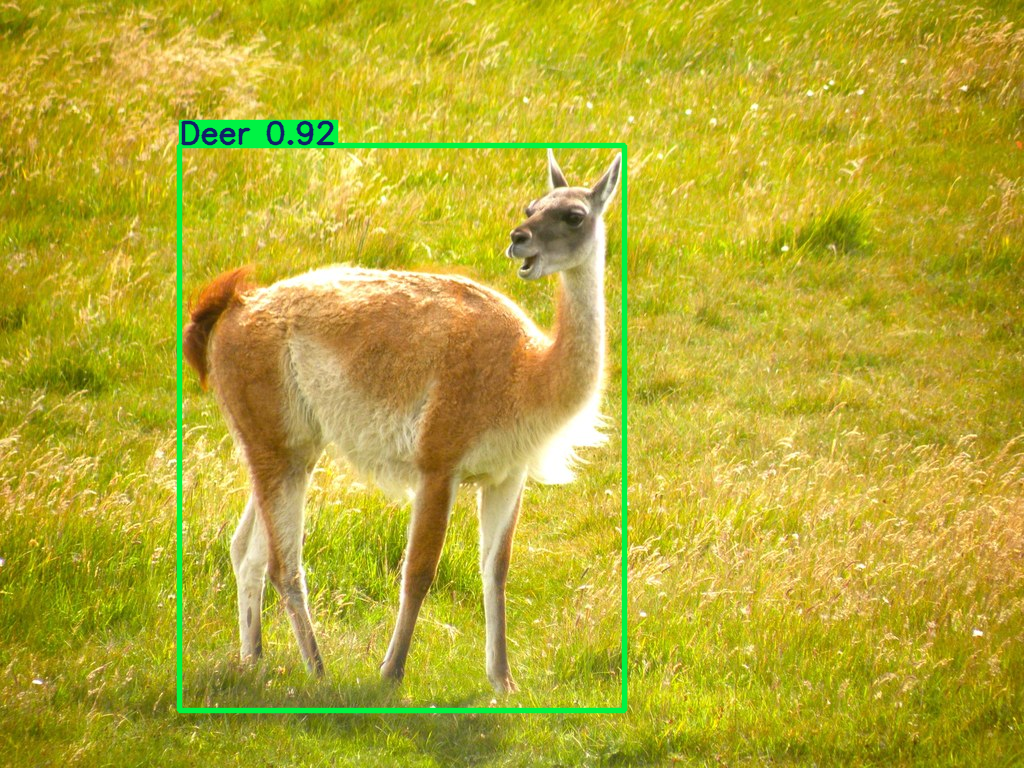

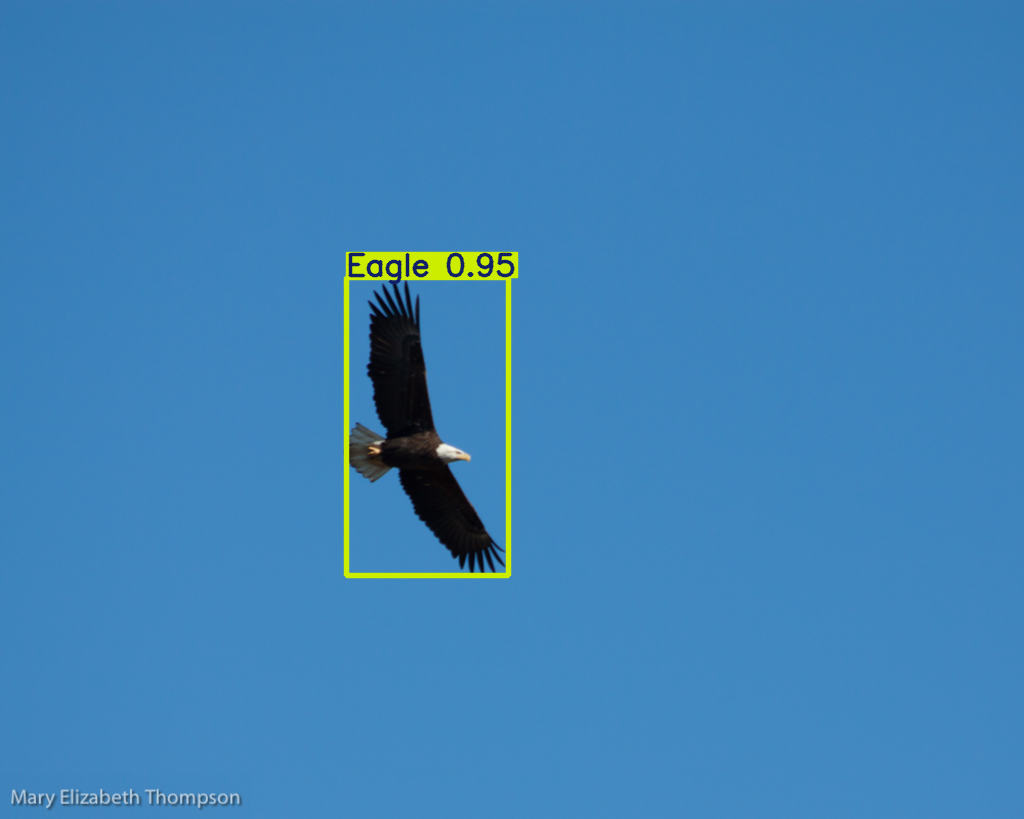

In [ ]:
model = YOLO("/content/runs/detect/train2/weights/best.pt")

image_paths = [
    "/content/yolo_animals/images/val/Deer_0285b398989179c8.jpg",
    "/content/yolo_animals/images/val/Eagle_fc64b58ebeebfa43.jpg"
]

results = model(image_paths)

for r in results:
    r.show()

In [ ]:
model.export(format="onnx")
model.export(format="tflite")
model.export(format="engine")  # TensorRT

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 13, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<=1.19.1', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 204ms
Prepared 6 packages in 9.98s
Installed 6 packages in 2.00s
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.19.1
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.78

requirements: AutoUpdate success ✅ 13.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.78...
ON

'/content/runs/detect/train2/weights/best.engine'